In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df1 = pd.read_csv('Salary.csv')
df2 = pd.read_csv('Salary_Data_Based_country_and_race.csv')

print("=== Salary.csv ===")
print(f"Shape: {df1.shape}")
print(df1.columns.tolist())
print(df1.head(3))

print("\n=== Salary_Data_Based_country_and_race.csv ===")
print(f"Shape: {df2.shape}")
print(df2.columns.tolist())
print(df2.head(3))

=== Salary.csv ===
Shape: (6684, 9)
['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience', 'Salary', 'Country', 'Race', 'Senior']
    Age  Gender  Education Level          Job Title  Years of Experience  \
0  32.0    Male                1  Software Engineer                  5.0   
1  28.0  Female                2       Data Analyst                  3.0   
2  45.0    Male                3            Manager                 15.0   

     Salary Country      Race  Senior  
0   90000.0      UK     White       0  
1   65000.0     USA  Hispanic       0  
2  150000.0  Canada     White       1  

=== Salary_Data_Based_country_and_race.csv ===
Shape: (6704, 9)
['Unnamed: 0', 'Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience', 'Salary', 'Country', 'Race']
   Unnamed: 0   Age  Gender Education Level          Job Title  \
0           0  32.0    Male      Bachelor's  Software Engineer   
1           1  28.0  Female        Master's       Data Analyst   
2       

In [2]:
print("=== Missing values in Salary.csv ===")
print(df1.isnull().sum())
print("\n=== Missing values in Salary_Data_Based_country_and_race.csv ===")
print(df2.isnull().sum())

=== Missing values in Salary.csv ===
Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
Country                0
Race                   0
Senior                 0
dtype: int64

=== Missing values in Salary_Data_Based_country_and_race.csv ===
Unnamed: 0             0
Age                    2
Gender                 2
Education Level        3
Job Title              2
Years of Experience    3
Salary                 5
Country                0
Race                   0
dtype: int64


In [3]:
# Use df2 as it has readable education labels
df = df2.copy()

# Drop the index column
df = df.drop('Unnamed: 0', axis=1)

# Drop rows with missing values (only 5 rows affected)
df = df.dropna()

# Clean up column names
df.columns = ['Age', 'Gender', 'Education', 'Job Title', 'Experience', 'Salary', 'Country', 'Race']

print(f"Clean dataset shape: {df.shape}")
print(f"\nUnique Job Titles: {df['Job Title'].nunique()}")
print(f"Unique Countries: {df['Country'].unique()}")
print(f"Education levels: {df['Education'].unique()}")
print(f"Salary range: ${df['Salary'].min():,.0f} — ${df['Salary'].max():,.0f}")
print(f"Average salary: ${df['Salary'].mean():,.0f}")

Clean dataset shape: (6698, 8)

Unique Job Titles: 191
Unique Countries: ['UK' 'USA' 'Canada' 'China' 'Australia']
Education levels: ["Bachelor's" "Master's" 'PhD' "Bachelor's Degree" "Master's Degree"
 'High School' 'phD']
Salary range: $350 — $250,000
Average salary: $115,329


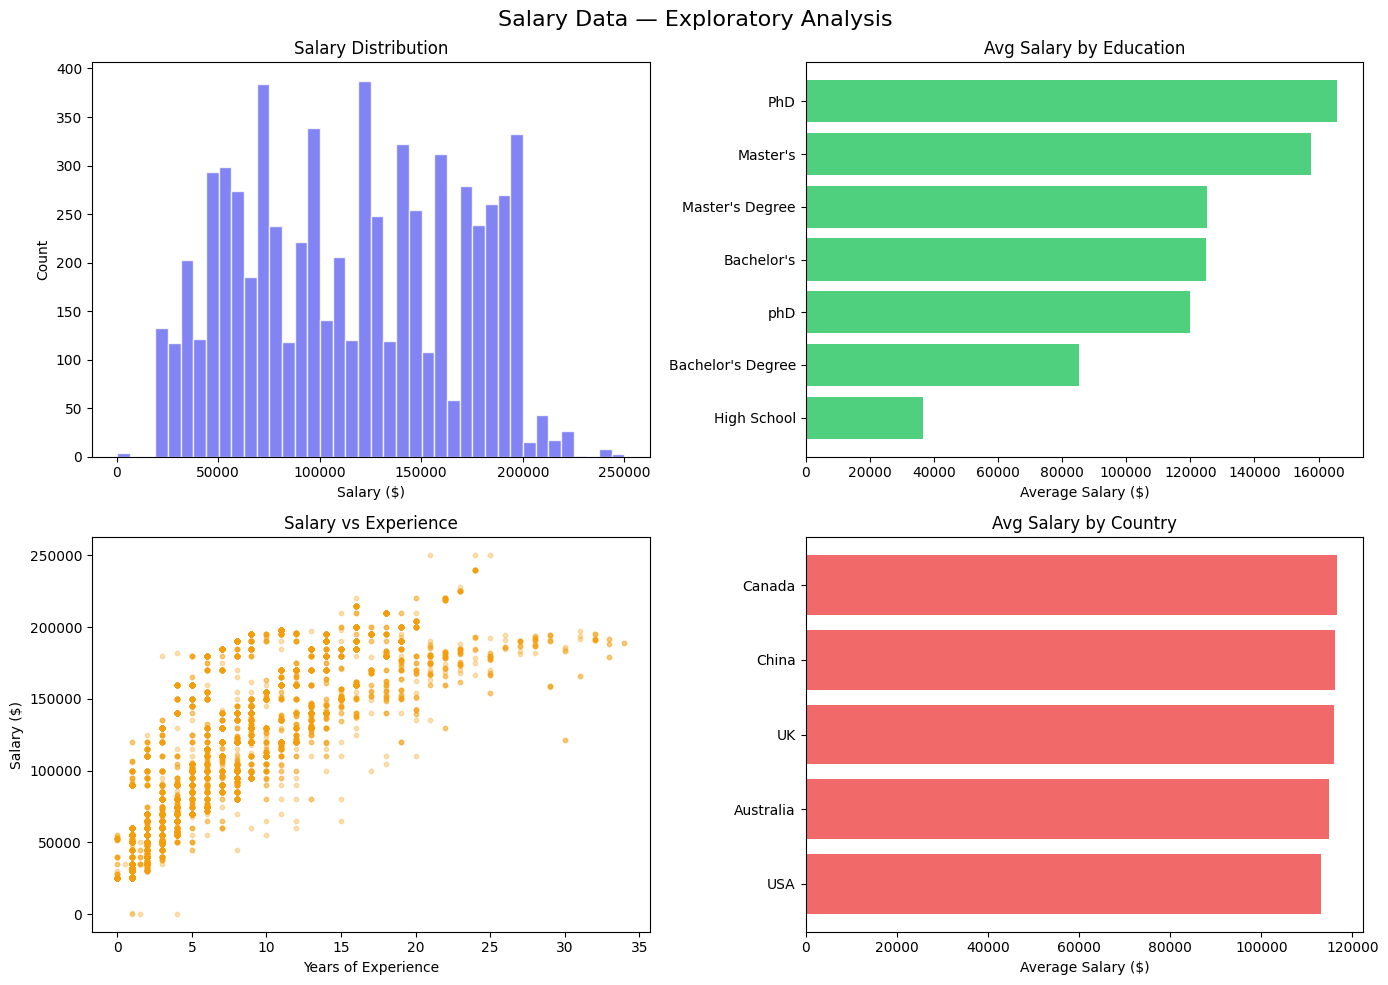

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Salary Data — Exploratory Analysis', fontsize=16)

# 1. Salary distribution
axes[0,0].hist(df['Salary'], bins=40, color='#6366f1', alpha=0.8, edgecolor='white')
axes[0,0].set_title('Salary Distribution')
axes[0,0].set_xlabel('Salary ($)')
axes[0,0].set_ylabel('Count')

# 2. Avg salary by education
edu_salary = df.groupby('Education')['Salary'].mean().sort_values()
axes[0,1].barh(edu_salary.index, edu_salary.values, color='#22c55e', alpha=0.8)
axes[0,1].set_title('Avg Salary by Education')
axes[0,1].set_xlabel('Average Salary ($)')

# 3. Salary by experience (scatter)
axes[1,0].scatter(df['Experience'], df['Salary'], alpha=0.3, color='#f59e0b', s=10)
axes[1,0].set_title('Salary vs Experience')
axes[1,0].set_xlabel('Years of Experience')
axes[1,0].set_ylabel('Salary ($)')

# 4. Avg salary by country
country_salary = df.groupby('Country')['Salary'].mean().sort_values()
axes[1,1].barh(country_salary.index, country_salary.values, color='#ef4444', alpha=0.8)
axes[1,1].set_title('Avg Salary by Country')
axes[1,1].set_xlabel('Average Salary ($)')

plt.tight_layout()
plt.show()

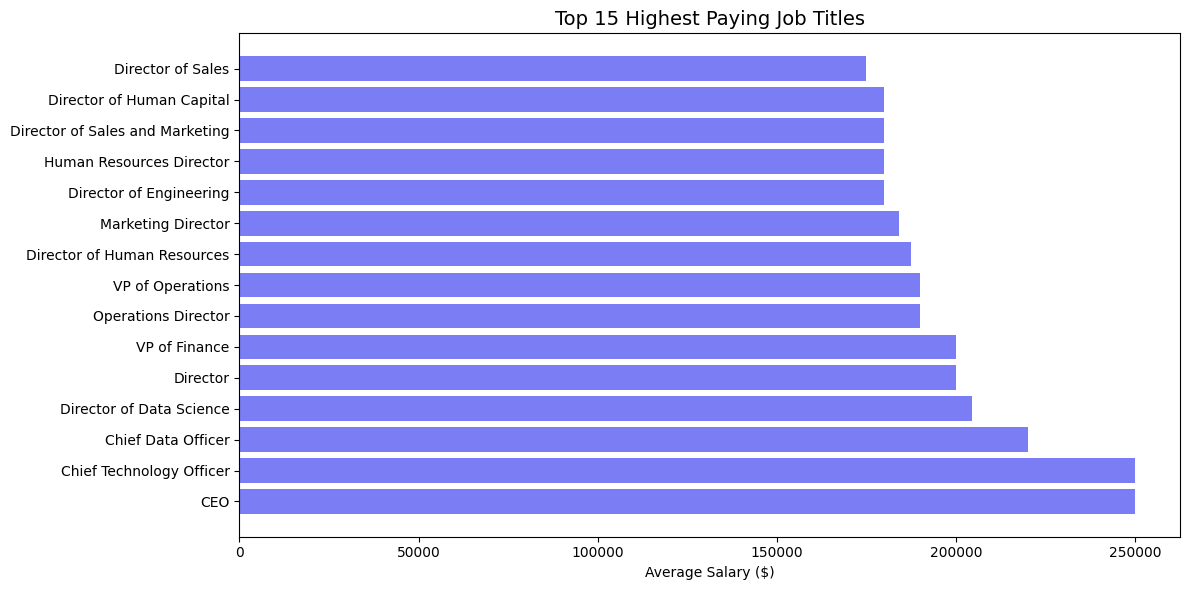


Top 10 highest paying jobs:
Job Title
CEO                            $250,000
Chief Technology Officer       $250,000
Chief Data Officer             $220,000
Director of Data Science       $204,561
Director                       $200,000
VP of Finance                  $200,000
Operations Director            $190,000
VP of Operations               $190,000
Director of Human Resources    $187,500
Marketing Director             $183,984
Name: Salary, dtype: object


In [5]:
top_jobs = df.groupby('Job Title')['Salary'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 6))
bars = plt.barh(top_jobs.index, top_jobs.values, color='#6366f1', alpha=0.85)
plt.title('Top 15 Highest Paying Job Titles', fontsize=14)
plt.xlabel('Average Salary ($)')
plt.tight_layout()
plt.show()

print("\nTop 10 highest paying jobs:")
print(top_jobs.head(10).apply(lambda x: f"${x:,.0f}"))

In [6]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pickle, os

# Encode categorical columns
df_model = df.copy()
le_job = LabelEncoder()
le_edu = LabelEncoder()
le_country = LabelEncoder()
le_gender = LabelEncoder()

df_model['Job Title']  = le_job.fit_transform(df_model['Job Title'])
df_model['Education']  = le_edu.fit_transform(df_model['Education'])
df_model['Country']    = le_country.fit_transform(df_model['Country'])
df_model['Gender']     = le_gender.fit_transform(df_model['Gender'])

# Features and target
features = ['Age', 'Gender', 'Education', 'Job Title', 'Experience', 'Country']
X = df_model[features]
y = df_model['Salary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

# Train 3 models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)
    results[name] = {'model': model, 'rmse': rmse, 'r2': r2}
    print(f"{name:25s} → RMSE: ${rmse:,.0f}  |  R²: {r2:.4f}")

best_name = max(results, key=lambda x: results[x]['r2'])
best_model = results[best_name]['model']
print(f"\n🏆 Best model: {best_name} (R²: {results[best_name]['r2']:.4f})")

Training: 5358 rows | Test: 1340 rows
Linear Regression         → RMSE: $30,453  |  R²: 0.6748
Random Forest             → RMSE: $8,469  |  R²: 0.9748
Gradient Boosting         → RMSE: $13,603  |  R²: 0.9351

🏆 Best model: Random Forest (R²: 0.9748)


In [7]:
os.makedirs('../backend/models', exist_ok=True)

# Save everything needed for the API
pickle.dump(best_model,  open('../backend/models/salary_model.pkl', 'wb'))
pickle.dump(le_job,      open('../backend/models/le_job.pkl', 'wb'))
pickle.dump(le_edu,      open('../backend/models/le_edu.pkl', 'wb'))
pickle.dump(le_country,  open('../backend/models/le_country.pkl', 'wb'))
pickle.dump(le_gender,   open('../backend/models/le_gender.pkl', 'wb'))

# Save known categories for the UI dropdowns
import json
meta = {
    'job_titles': sorted(df['Job Title'].unique().tolist()),
    'education':  sorted(df['Education'].unique().tolist()),
    'countries':  sorted(df['Country'].unique().tolist()),
    'genders':    sorted(df['Gender'].unique().tolist()),
}
json.dump(meta, open('../backend/models/meta.json', 'w'))

print("✅ Model and encoders saved!")
print(f"\n📋 Dropdown options:")
print(f"  Job titles: {len(meta['job_titles'])} options")
print(f"  Countries:  {meta['countries']}")
print(f"  Education:  {meta['education']}")

# Test prediction
sample = pd.DataFrame([{
    'Age': 28, 'Gender': le_gender.transform(['Male'])[0],
    'Education': le_edu.transform(["Bachelor's"])[0],
    'Job Title': le_job.transform(['Data Scientist'])[0],
    'Experience': 3, 'Country': le_country.transform(['USA'])[0]
}])
pred = best_model.predict(sample)[0]
print(f"\n🧪 Test prediction — Data Scientist, 3 yrs exp, USA, Bachelor's:")
print(f"   Predicted salary: ${pred:,.0f}")

✅ Model and encoders saved!

📋 Dropdown options:
  Job titles: 191 options
  Countries:  ['Australia', 'Canada', 'China', 'UK', 'USA']
  Education:  ["Bachelor's", "Bachelor's Degree", 'High School', "Master's", "Master's Degree", 'PhD', 'phD']

🧪 Test prediction — Data Scientist, 3 yrs exp, USA, Bachelor's:
   Predicted salary: $91,850


In [8]:
# Standardize messy education labels
edu_map = {
    "Bachelor's": "Bachelor's",
    "Bachelor's Degree": "Bachelor's",
    "Master's": "Master's",
    "Master's Degree": "Master's",
    'PhD': 'PhD',
    'phD': 'PhD',
    'High School': 'High School'
}

df['Education'] = df['Education'].map(edu_map)
print("Fixed education labels:", df['Education'].unique())
print(df['Education'].value_counts())

Fixed education labels: ["Bachelor's" "Master's" 'PhD' 'High School']
Education
Bachelor's     3021
Master's       1860
PhD            1369
High School     448
Name: count, dtype: int64


In [9]:
df_model2 = df.copy()

le_job2      = LabelEncoder()
le_edu2      = LabelEncoder()
le_country2  = LabelEncoder()
le_gender2   = LabelEncoder()

df_model2['Job Title'] = le_job2.fit_transform(df_model2['Job Title'])
df_model2['Education'] = le_edu2.fit_transform(df_model2['Education'])
df_model2['Country']   = le_country2.fit_transform(df_model2['Country'])
df_model2['Gender']    = le_gender2.fit_transform(df_model2['Gender'])

X2 = df_model2[features]
y2 = df_model2['Salary']
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42)

best_model2 = RandomForestRegressor(n_estimators=100, random_state=42)
best_model2.fit(X_train2, y_train2)
preds2 = best_model2.predict(X_test2)
print(f"Retrained R²: {r2_score(y_test2, preds2):.4f}")

# Overwrite saved files with clean version
pickle.dump(best_model2, open('../backend/models/salary_model.pkl', 'wb'))
pickle.dump(le_job2,     open('../backend/models/le_job.pkl', 'wb'))
pickle.dump(le_edu2,     open('../backend/models/le_edu.pkl', 'wb'))
pickle.dump(le_country2, open('../backend/models/le_country.pkl', 'wb'))
pickle.dump(le_gender2,  open('../backend/models/le_gender.pkl', 'wb'))

meta2 = {
    'job_titles': sorted(df['Job Title'].unique().tolist()),
    'education':  sorted(df['Education'].unique().tolist()),
    'countries':  sorted(df['Country'].unique().tolist()),
    'genders':    sorted(df['Gender'].unique().tolist()),
}
json.dump(meta2, open('../backend/models/meta.json', 'w'))
print("✅ Clean model saved!")
print("Education options:", meta2['education'])

# Test again
sample2 = pd.DataFrame([{
    'Age': 28,
    'Gender': le_gender2.transform(['Male'])[0],
    'Education': le_edu2.transform(["Bachelor's"])[0],
    'Job Title': le_job2.transform(['Data Scientist'])[0],
    'Experience': 3,
    'Country': le_country2.transform(['USA'])[0]
}])
pred2 = best_model2.predict(sample2)[0]
print(f"\n🧪 Data Scientist, 3yrs, USA, Bachelor's → ${pred2:,.0f} USD = ₹{pred2*83.5:,.0f} INR")

Retrained R²: 0.9654
✅ Clean model saved!
Education options: ["Bachelor's", 'High School', "Master's", 'PhD']

🧪 Data Scientist, 3yrs, USA, Bachelor's → $94,996 USD = ₹7,932,129 INR
